# Import All Libraries

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
import joblib

# Data Loading and Inspection

In [2]:
# Data
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Top 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset shape
df.shape

(7043, 21)

In [5]:
# Column names
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Check for null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Preprocessing

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df.drop('customerID', axis=1, inplace=True)
print("NaN values after fix:", df.isnull().sum().sum())

NaN values after fix: 0


# Exploratory Data Analysis (EDA)

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


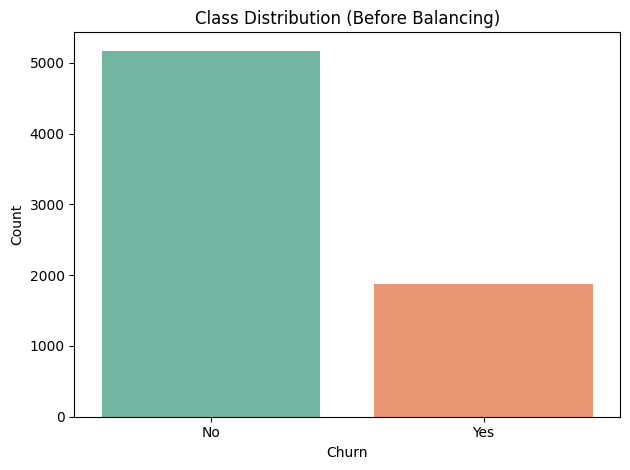

In [10]:
# Plot 1: Class distribution
print("Churn value counts:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Class Distribution (Before Balancing)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

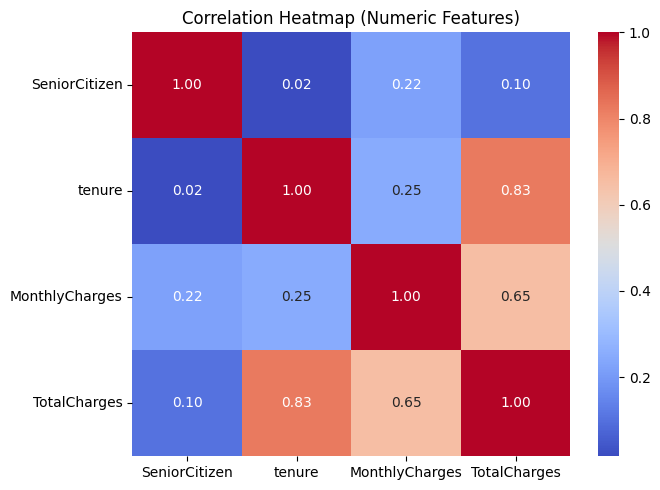

In [11]:
# Plot 2: Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

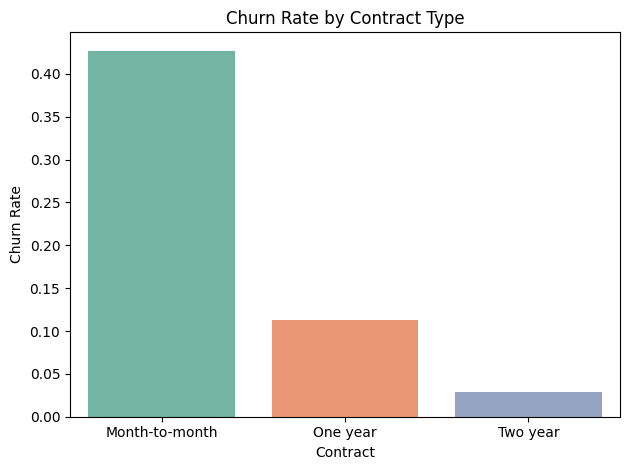

In [12]:
# Plot 3: Churn rate by Contract type
# Month-to-month customers churn at ~43% vs ~3% for 2-year contracts
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean()).reset_index()
churn_by_contract.columns = ['Contract', 'Churn_Rate']

sns.barplot(x='Contract', y='Churn_Rate', data=churn_by_contract,
            hue='Contract', palette='Set2', legend=False)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()

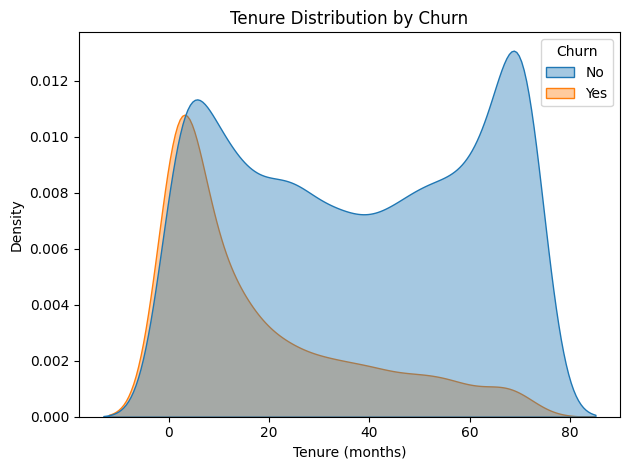

In [13]:
# Plot 4: Tenure distribution by churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, alpha=0.4)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

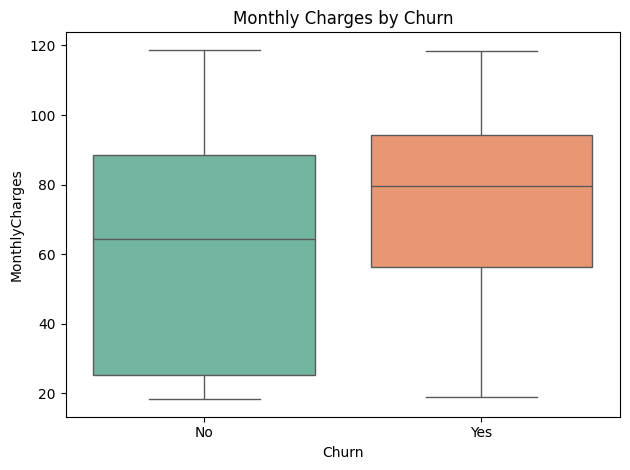

In [14]:
# Plot 5: Monthly charges by churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn')
plt.tight_layout()
plt.show()

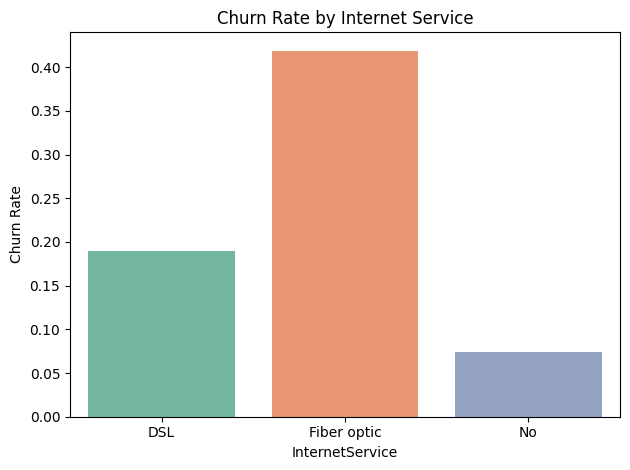

In [15]:
# Plot 6: Churn rate by Internet Service type
churn_by_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
churn_by_internet.columns = ['InternetService', 'Churn_Rate']

sns.barplot(x='InternetService', y='Churn_Rate', data=churn_by_internet, 
            hue='InternetService', palette='Set2', legend=False)
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()

# Feature Engineering

In [16]:
# Tenure group — captures the non-linear early-churn pattern
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']
)

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean()).reset_index()
churn_by_tenure.columns = ['Tenure Group', 'Churn Rate']
print(churn_by_tenure)

  Tenure Group  Churn Rate
0        0-1yr    0.476782
1        1-2yr    0.287109
2        2-4yr    0.203890
3        4-5yr    0.144231
4        5-6yr    0.066098


# Encoding

In [17]:
# Binary columns (2 unique values like Yes/No): map()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# Multi-class columns (3+ unique values): get_dummies()
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Final shape after encoding:", df.shape)
print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())

Final shape after encoding: (7043, 35)
Remaining object columns: []


# Train - Test Split

In [18]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42, stratify=y)

print("X_train shape:",x_train.shape)
print("X_test shape:",x_test.shape)
print("Y_train shape:",y_train.shape)
print("Y_test shape:",y_test.shape)

X_train shape: (5634, 34)
X_test shape: (1409, 34)
Y_train shape: (5634,)
Y_test shape: (1409,)


# Class Imbalance Handling

In [19]:
# Class counts in training set
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

print(f"Training set: {neg} non-churners, {pos} churners")
print(f"scale_pos_weight for XGBoost: {scale_pos:.2f}")

Training set: 4139 non-churners, 1495 churners
scale_pos_weight for XGBoost: 2.77


In [20]:
# For Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)   
X_test_scaled  = scaler.transform(x_test)       

# Model Training and Evaluation

In [21]:
def model_evaluation(model, name, X_tr, Y_tr, X_te, Y_te):
    
    model.fit(X_tr, Y_tr)
    y_pred = model.predict(X_te)

    train_acc = accuracy_score(model.predict(X_tr), Y_tr)
    test_acc  = accuracy_score(y_pred, Y_te)

    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing  Accuracy : {test_acc:.4f}")
    print()
    print(classification_report(Y_te, y_pred))

    cm = confusion_matrix(Y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return model

  Logistic Regression
Training Accuracy : 0.7531
Testing  Accuracy : 0.7353

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



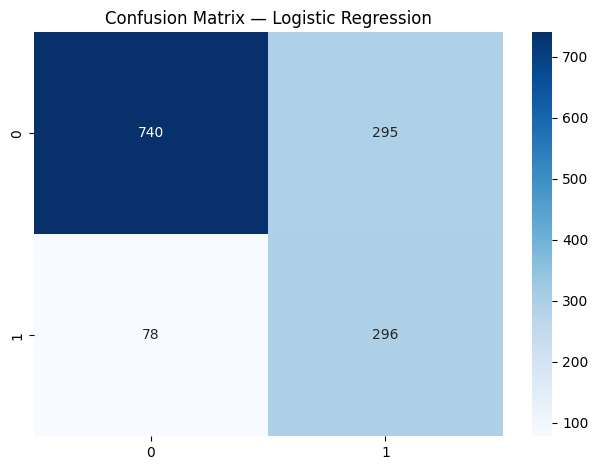

In [22]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
model_lr = model_evaluation(model_lr, 'Logistic Regression',
                             X_train_scaled, y_train, X_test_scaled, y_test)

In [23]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42))])
scores_lr = cross_val_score(lr_pipeline, x_train, y_train, cv=5, scoring='f1')
print(f"Logistic Regression CV F1: {scores_lr.mean():.3f} ± {scores_lr.std():.3f}")

Logistic Regression CV F1: 0.627 ± 0.025


  Decision Tree
Training Accuracy : 0.9979
Testing  Accuracy : 0.7339

              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1035
           1       0.50      0.48      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



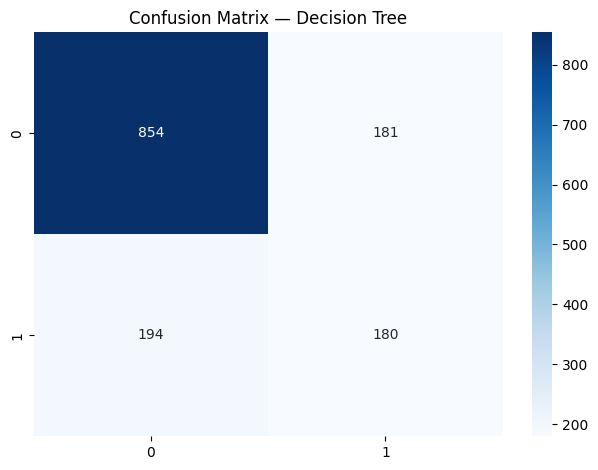

In [24]:
# Decision Tree
model_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model_dt = model_evaluation(model_dt, 'Decision Tree', x_train, y_train, x_test, y_test)

In [25]:
dt_cv = DecisionTreeClassifier(class_weight='balanced', random_state=42)
scores_dt = cross_val_score(dt_cv, x_train, y_train, cv=5, scoring='f1')
print(f"Decision Tree CV F1: {scores_dt.mean():.3f} ± {scores_dt.std():.3f}")

Decision Tree CV F1: 0.495 ± 0.023


  Random Forest
Training Accuracy : 0.9980
Testing  Accuracy : 0.7878

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



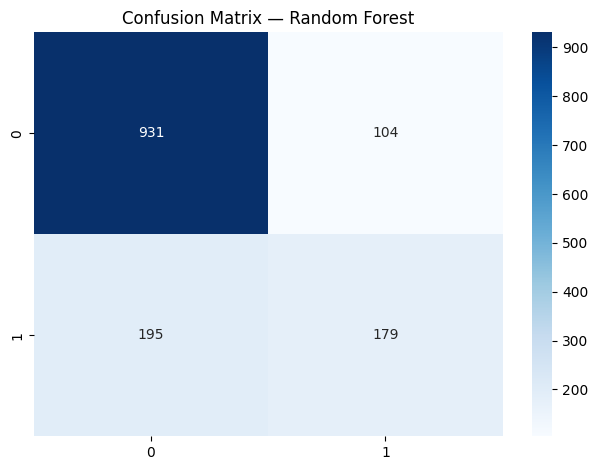

In [26]:
# Random Forest

model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf = model_evaluation(model_rf, 'Random Forest', x_train, y_train, x_test, y_test)

In [27]:
rf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
scores_rf = cross_val_score(rf_cv, x_train, y_train, cv=5, scoring='f1')
print(f"Random Forest CV F1: {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

Random Forest CV F1: 0.534 ± 0.031


  XGBoost
Training Accuracy : 0.9239
Testing  Accuracy : 0.7573

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      1035
           1       0.53      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



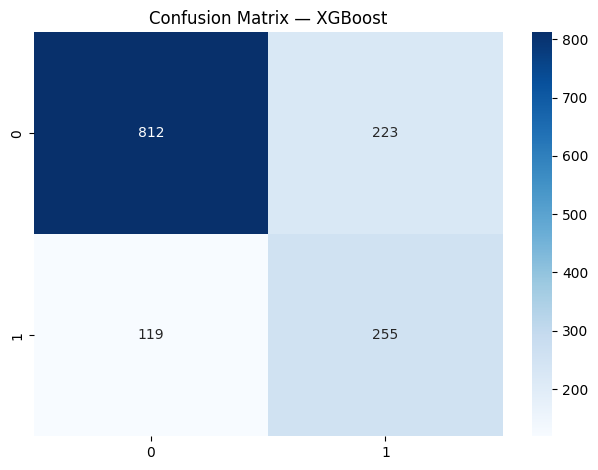

In [28]:
# XGBoost
model_xgb = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)
model_xgb = model_evaluation(model_xgb, 'XGBoost', x_train, y_train, x_test, y_test)

In [29]:
xgb_cv = XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
scores_xgb = cross_val_score(xgb_cv, x_train, y_train, cv=5, scoring='f1')
print(f"XGBoost CV F1: {scores_xgb.mean():.3f} ± {scores_xgb.std():.3f}")

XGBoost CV F1: 0.589 ± 0.022


  LightGBM
Training Accuracy : 0.8774
Testing  Accuracy : 0.7594

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



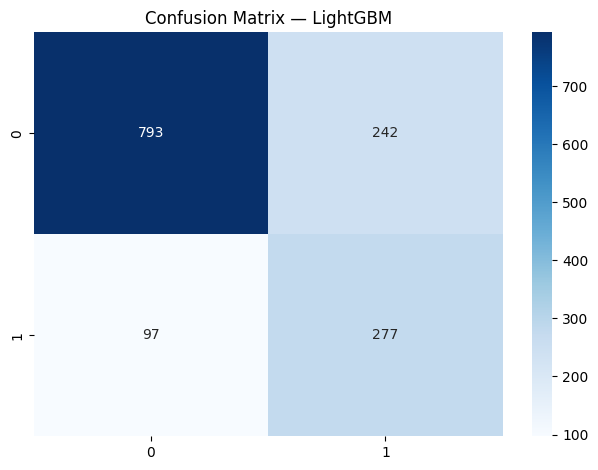

In [30]:
#LightBgm
model_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
model_lgbm = model_evaluation(model_lgbm, 'LightGBM', x_train, y_train, x_test, y_test)

In [31]:
lgbm_cv = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                          class_weight='balanced', random_state=42, verbose=-1)
scores_lgbm = cross_val_score(lgbm_cv, x_train, y_train, cv=5, scoring='f1')
print(f"LightGBM CV F1: {scores_lgbm.mean():.3f} ± {scores_lgbm.std():.3f}")

LightGBM CV F1: 0.612 ± 0.019


# Hyperparameter Tuning (XGBoost)

In [32]:
params = {
    'max_depth':      [3, 4, 5, 6],
    'n_estimators':   [100, 200, 300],
    'learning_rate':  [0.01, 0.05, 0.1],
    'subsample':      [0.8, 1.0],
    'min_child_weight': [1, 3]
}

gs = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss'),
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gs.fit(x_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV F1: ", gs.best_score_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1:  0.6393810507560272


Best XGBoost — Test Set Performance
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



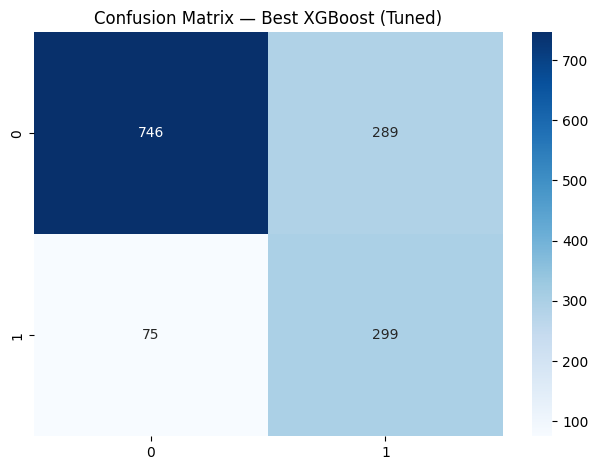

In [33]:
best_xgb = gs.best_estimator_
final_pred = best_xgb.predict(x_test)

print("Best XGBoost — Test Set Performance")
print("="*45)
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Best XGBoost (Tuned)')
plt.tight_layout()
plt.show()

# Model Comparison

In [34]:
results = {
    'Logistic Regression': {
        'CV F1 Mean': scores_lr.mean(),
        'CV F1 Std':  scores_lr.std(),
        'Test F1':    f1_score(y_test, model_lr.predict(X_test_scaled))
    },
    'Decision Tree': {
        'CV F1 Mean': scores_dt.mean(),
        'CV F1 Std':  scores_dt.std(),
        'Test F1':    f1_score(y_test, model_dt.predict(x_test))
    },
    'Random Forest': {
        'CV F1 Mean': scores_rf.mean(),
        'CV F1 Std':  scores_rf.std(),
        'Test F1':    f1_score(y_test, model_rf.predict(x_test))
    },
    'XGBoost (default)': {
        'CV F1 Mean': scores_xgb.mean(),
        'CV F1 Std':  scores_xgb.std(),
        'Test F1':    f1_score(y_test, model_xgb.predict(x_test))
    },
    'LightGBM': {
        'CV F1 Mean': scores_lgbm.mean(),
        'CV F1 Std':  scores_lgbm.std(),
        'Test F1':    f1_score(y_test, model_lgbm.predict(x_test))
    },
    'XGBoost (tuned)': {
        'CV F1 Mean': gs.best_score_,
        'CV F1 Std':  None,
        'Test F1':    f1_score(y_test, final_pred)
    }
}

results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values('Test F1', ascending=False)
print(results_df.to_string())

                     CV F1 Mean  CV F1 Std  Test F1
XGBoost (tuned)           0.639        NaN    0.622
LightGBM                  0.612      0.019    0.620
Logistic Regression       0.627      0.025    0.613
XGBoost (default)         0.589      0.022    0.599
Random Forest             0.534      0.031    0.545
Decision Tree             0.495      0.023    0.490


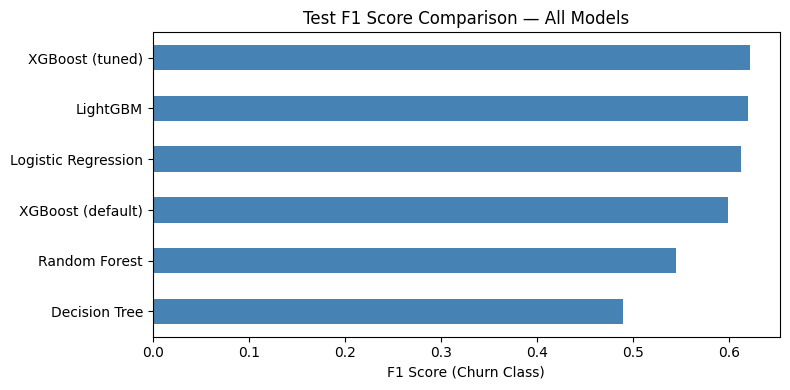

In [35]:
# Visual comparison of Test F1 across all models
results_df['Test F1'].sort_values().plot(
    kind='barh', figsize=(8, 4), color='steelblue',
    title='Test F1 Score Comparison — All Models'
)
plt.xlabel('F1 Score (Churn Class)')
plt.tight_layout()
plt.show()

# ROC Curves

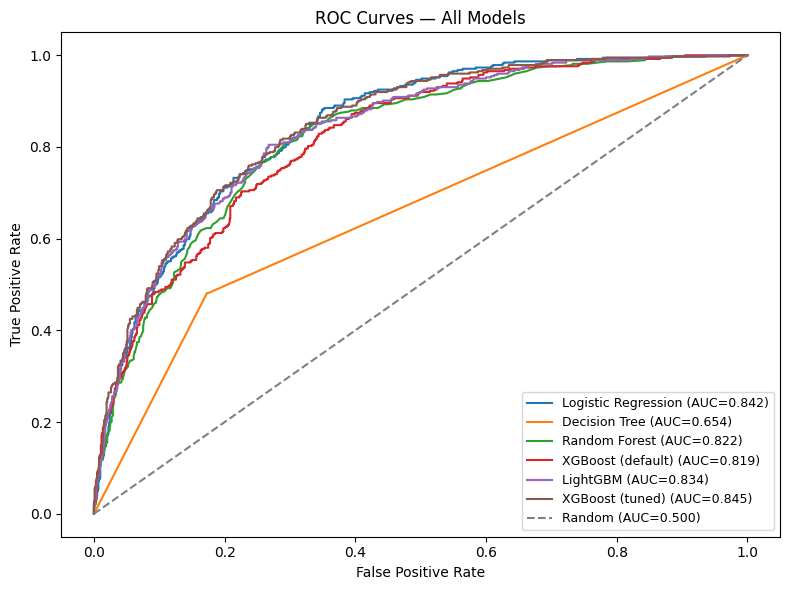

In [36]:
models_for_roc = {
    'Logistic Regression': (model_lr,   X_test_scaled),
    'Decision Tree':       (model_dt,   x_test),
    'Random Forest':       (model_rf,   x_test),
    'XGBoost (default)':   (model_xgb,  x_test),
    'LightGBM':            (model_lgbm, x_test),
    'XGBoost (tuned)':     (best_xgb,   x_test),
}

plt.figure(figsize=(8, 6))

for name, (model, X_t) in models_for_roc.items():
    prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# Feature Importance

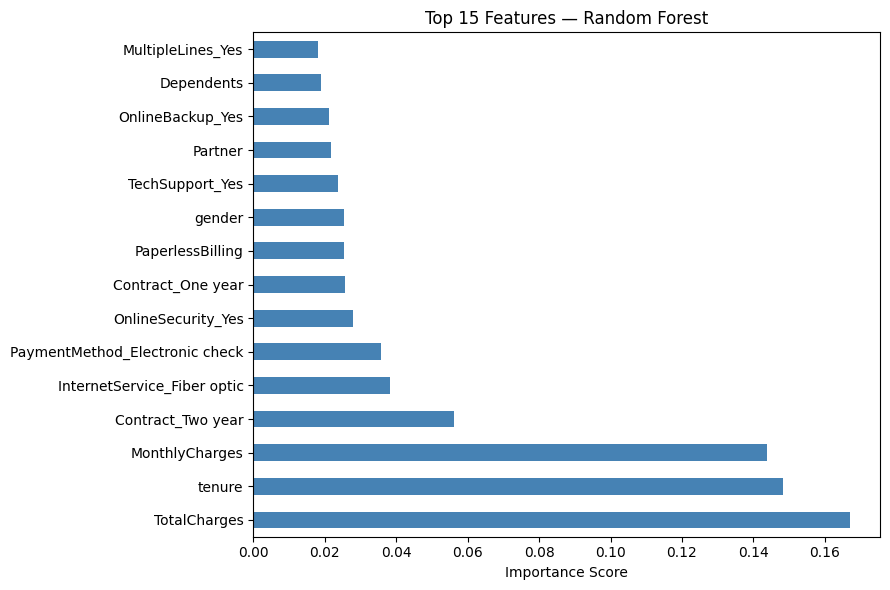

In [37]:
# Random Forest feature importance
feat_imp_rf = pd.Series(
    model_rf.feature_importances_,
    index=X.columns).nlargest(15)

plt.figure(figsize=(9, 6))
feat_imp_rf.plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

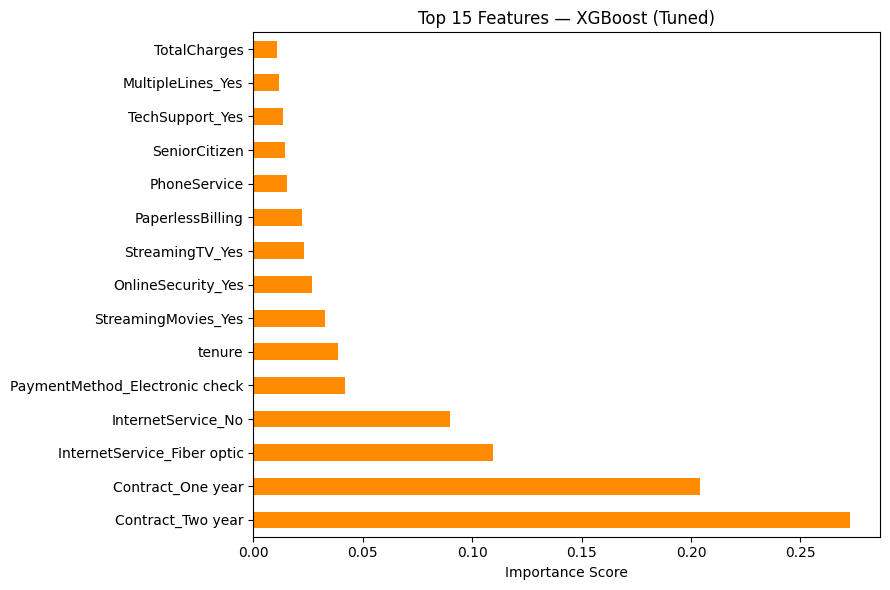

In [38]:
# XGBoost feature importance (tuned model)
feat_imp_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns).nlargest(15)

plt.figure(figsize=(9, 6))
feat_imp_xgb.plot(kind='barh', color='darkorange')
plt.title('Top 15 Features — XGBoost (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Save Model

In [39]:
# Save best XGBoost model and scaler
joblib.dump(best_xgb, 'best_churn_model.pkl')
joblib.dump(scaler,   'scaler.pkl')

print("Models saved:")
print("  best_churn_model.pkl  — tuned XGBoost (best F1 on churn class)")
print("  scaler.pkl            — StandardScaler (needed for Logistic Regression inference)")

# Verification: reload and predict on first 5 test samples
loaded_model = joblib.load('best_churn_model.pkl')
verify_pred = loaded_model.predict(x_test[:5])
print("\nVerification — predictions on first 5 test samples:", verify_pred)
print("Actual values:                                      ", y_test.values[:5])

Models saved:
  best_churn_model.pkl  — tuned XGBoost (best F1 on churn class)
  scaler.pkl            — StandardScaler (needed for Logistic Regression inference)

Verification — predictions on first 5 test samples: [0 1 0 1 0]
Actual values:                                       [0 0 0 0 0]
